# Friedkin–Johnsen Latent Belief Baseline (Alpha-Only)

Layer split used here:
- latent state $z_i(t)$ defaults to the profile proxy `topology_profile_for_agent.ss`
- optionally, $z_i(t)$ can be loaded from `latent_belief_global.jsonl` (global latent-belief pipeline output)
- observed message stance $x_i(t)$ is read from `messages_with_alignment.jsonl` (`published.stance_score`)
- expressive noise is $\eta_i(t)=x_i(t)-z_i(t)$

Alpha-only FJ baseline on latent belief state:
$$z_i(t+1)=\alpha z_i(0)+(1-\alpha)\,\text{social}_i(t).$$

Observed stance $x_i(t)$ is used only for expression diagnostics.

In [ ]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
ROOT = Path.cwd().parent.parent  # Adjust as needed to point to the project root
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

# If available, prefer the exported global innate-belief file created by
# `latent_belief/degroot_gaussian_noise_study.ipynb`.
USE_GLOBAL_LATENT = True
GLOBAL_LATENT_FILENAME = 'latent_belief_global.jsonl'
# Default: use the debiased innate belief (no smoothing baked in here).
GLOBAL_LATENT_FIELD = 'z_innate_debiased'

PARAMS = {
    # Denser baseline sweep; still alpha-only.
    'alpha_grid': np.linspace(0.0, 1.0, 21).tolist(),
}


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def to_int_list(values):
    out = []
    if not isinstance(values, list):
        return out
    for x in values:
        try:
            out.append(int(x))
        except Exception:
            continue
    return out


def build_events_from_per_agent(run_dir: Path):
    events = []
    obs_seq_by_agent = defaultdict(list)
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return events, obs_seq_by_agent
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        target = fp.stem
        for row in load_jsonl(fp):
            topo = row.get('topology_profile_for_agent', {}) or {}
            ss = topo.get('ss', None)
            msg_index = row.get('message_index', None)
            if ss is None or msg_index is None:
                continue
            rec_indices = to_int_list(row.get('recommendation_indices'))
            if not rec_indices:
                rec_indices = to_int_list(row.get('used_indices'))
            sender = parse_agent_id(row.get('influenced_by'))
            events.append(
                {
                    't': int(msg_index),
                    'target': target,
                    'sender': sender,
                    'obs_z': float(ss),
                    'message_text': row.get('message', '') or '',
                    'rec_indices': rec_indices,
                }
            )
            obs_seq_by_agent[target].append(float(ss))
    events.sort(key=lambda e: (e['t'], numeric_agent_key(e['target'])))
    return events, obs_seq_by_agent


def build_events_from_global_latent(run_dir: Path, z_field: str = GLOBAL_LATENT_FIELD):
    """Load per-event innate beliefs exported by the global noise-debias pipeline."""

    fp = run_dir / GLOBAL_LATENT_FILENAME
    events = []
    obs_seq_by_agent = defaultdict(list)
    if not fp.exists():
        return events, obs_seq_by_agent

    for row in load_jsonl(fp):
        if isinstance(row, dict) and '_meta' in row:
            continue
        if not isinstance(row, dict):
            continue
        t = row.get('t', None)
        agent = row.get('agent', None)
        if t is None or agent is None:
            continue
        try:
            t = int(t)
        except Exception:
            continue

        z_val = row.get(z_field, None)
        obs_z = float(z_val) if z_val is not None else np.nan

        obs_x = row.get('obs_x', None)
        obs_x = float(obs_x) if obs_x is not None else np.nan

        social = row.get('social', None)
        social = float(social) if social is not None else np.nan

        events.append(
            {
                't': t,
                'target': str(agent),
                'sender': None,
                'obs_z': obs_z,
                'obs_x': obs_x,
                'social': social,
                'rec_indices': [],
            }
        )
        if np.isfinite(obs_z):
            obs_seq_by_agent[str(agent)].append(float(obs_z))

    events.sort(key=lambda e: (e['t'], numeric_agent_key(e['target'])))
    return events, obs_seq_by_agent


def build_message_lookup(run_dir: Path):
    lookup = {}
    messages = load_jsonl(run_dir / 'messages_with_alignment.jsonl')
    for m in messages:
        idx = m.get('index', None)
        if idx is None:
            continue
        try:
            k = int(idx)
        except Exception:
            continue
        lookup[k] = {
            'sender': parse_agent_id(m.get('sender_id')),
            'obs_x': float((m.get('published') or {}).get('stance_score'))
            if (m.get('published') or {}).get('stance_score') is not None
            else np.nan,
        }
    return lookup


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def obs_count(run_dir: Path):
    if USE_GLOBAL_LATENT and (run_dir / GLOBAL_LATENT_FILENAME).exists():
        ev, _ = build_events_from_global_latent(run_dir)
        return len(ev)
    events, _ = build_events_from_per_agent(run_dir)
    return len(events)


RUN_DIR = max(RUN_DIRS, key=obs_count)
print('Using run:', RUN_DIR.name, 'event_obs=', obs_count(RUN_DIR))
print('Using global latent file:', bool(USE_GLOBAL_LATENT and (RUN_DIR / GLOBAL_LATENT_FILENAME).exists()))


def load_run_data(run_dir: Path):
    graph_raw = load_json(run_dir / 'connection_graph.json')
    graph = get_graph_adjacency(graph_raw)

    if USE_GLOBAL_LATENT and (run_dir / GLOBAL_LATENT_FILENAME).exists():
        events, obs_seq_by_agent = build_events_from_global_latent(run_dir)
    else:
        events, obs_seq_by_agent = build_events_from_per_agent(run_dir)

    message_lookup = build_message_lookup(run_dir)

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)

    for ev in events:
        agent_ids.add(ev['target'])
        if ev.get('sender') is not None:
            agent_ids.add(ev['sender'])

    for m in message_lookup.values():
        if m['sender'] is not None:
            agent_ids.add(m['sender'])

    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    return {
        'graph': graph,
        'events': events,
        'obs_seq_by_agent': obs_seq_by_agent,
        'agent_ids': agent_ids,
        'message_lookup': message_lookup,
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def initial_latent(obs_seq_by_agent, agent_ids):
    z0 = {a: 0.0 for a in agent_ids}
    for a in agent_ids:
        seq = obs_seq_by_agent.get(a, [])
        if seq:
            z0[a] = float(seq[0])
    return z0


def evaluate(records, pred_key='pred_x', obs_key='obs_x'):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan}
    d = np.array([r[pred_key] - r[obs_key] for r in records], dtype=float)
    return {'mae': float(np.mean(np.abs(d))), 'rmse': float(np.sqrt(np.mean(d * d))) }

Using run: run_20260217-223650 event_obs= 597
Using global latent file: True


In [ ]:
def run_event_fj_latent_z(data, alpha=0.6, prefer_event_obs_x=True, prefer_event_social=True):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    z_ref = initial_latent(data['obs_seq_by_agent'], agent_ids)

    z_scores = [float(ev['obs_z']) for ev in data['events']]

    x_scores = []
    for ev in data['events']:
        obs_x = ev.get('obs_x', None) if prefer_event_obs_x else None
        if obs_x is not None and np.isfinite(obs_x):
            x_scores.append(float(obs_x))
            continue
        x_scores.append(data['message_lookup'].get(ev['t'], {}).get('obs_x', np.nan))

    z0 = dict(z_ref)
    z_state = dict(z0)

    alpha = float(alpha)

    records = []
    for i, ev in enumerate(data['events']):
        target = ev['target']

        # Primary: reconstruct social term using graph + recommendation provenance.
        candidates = []
        for msg_idx in ev.get('rec_indices', []):
            meta = data['message_lookup'].get(msg_idx)
            if not meta:
                continue
            sender = meta['sender']
            if sender is None or sender not in z_state or sender == target:
                continue
            if sender not in preds.get(target, []):
                continue
            candidates.append(sender)

        if not candidates:
            sender = ev.get('sender', None)
            if sender in z_state and sender != target and sender in preds.get(target, []):
                candidates.append(sender)

        if candidates:
            social = float(np.mean([z_state[s] for s in candidates]))
        else:
            social = z_state[target]

        # Override: if the event supplies a precomputed social term (exported latent file), use it.
        if prefer_event_social:
            social_override = ev.get('social', None)
            if social_override is not None and np.isfinite(social_override):
                social = float(social_override)

        pred_z = alpha * z0[target] + (1.0 - alpha) * social
        obs_z = z_scores[i]
        obs_x = x_scores[i]
        eta = float(obs_x - obs_z) if np.isfinite(obs_x) and np.isfinite(obs_z) else np.nan
        belief_resid = float(obs_z - pred_z) if np.isfinite(obs_z) else np.nan
        expr_resid = float(obs_x - pred_z) if np.isfinite(obs_x) else np.nan

        if np.isfinite(obs_z):
            z_state[target] = float(obs_z)
        else:
            z_state[target] = float(pred_z)

        records.append(
            {
                't': ev['t'],
                'agent': target,
                'pred_z': float(pred_z),
                'obs_z': float(obs_z),
                'obs_x': float(obs_x) if np.isfinite(obs_x) else np.nan,
                'eta_hat': eta,
                'belief_resid': belief_resid,
                'expr_resid': expr_resid,
            }
        )

    return z_state, records, z0

## Flow of logic (simple)

1. Read latent proxy `z` from per-agent logs (`topology_profile_for_agent.ss`).
2. Read observed expression `x` from message logs (`published.stance_score`).
3. Compute expressive residual `η = x - z`.
4. Run FJ update on latent state only:
   $$z_i(t+1)=\alpha z_i(0)+(1-\alpha)\,\text{social}_i(t).$$
5. Evaluate prediction error against observed latent proxy `obs_z` (primary), and against `obs_x` only as diagnostic.

Data sources:
  z from: /home/sammli/llm-network/modeling/cleaned_data/run_20260217-223650/latent_belief_global.jsonl (field='z_innate_debiased')
  x from: /home/sammli/llm-network/modeling/cleaned_data/run_20260217-223650/latent_belief_global.jsonl (field='obs_x')
  social from: /home/sammli/llm-network/modeling/cleaned_data/run_20260217-223650/latent_belief_global.jsonl (field='social')

Counts:
  latent rows: 597
  expression rows: 597
  joined rows: 597
  missing x rate: 0.0


,t,target,obs_z_direct,social_direct,obs_x_direct,eta_direct
0,1,agent_1,0.603001,0.466058,0.383039,-0.219962
1,2,agent_12,0.589149,0.553689,0.397116,-0.192032
2,3,agent_9,0.670895,0.525701,0.492003,-0.178892
3,4,agent_15,0.707820,0.525701,0.536582,-0.171238
4,5,agent_18,0.708115,0.517847,0.549139,-0.158976
5,6,agent_28,0.718583,0.592720,0.528661,-0.189922
6,7,agent_4,0.638311,0.509992,0.434949,-0.203362
7,8,agent_21,0.650749,0.466058,0.471848,-0.178901
8,9,agent_22,0.681367,0.494198,0.500842,-0.180525
9,10,agent_16,0.431579,0.466851,0.185240,-0.246339


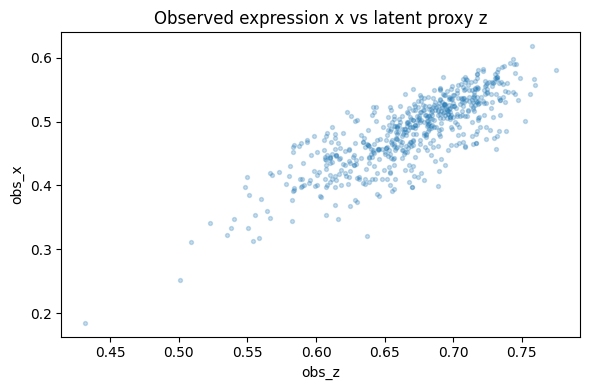

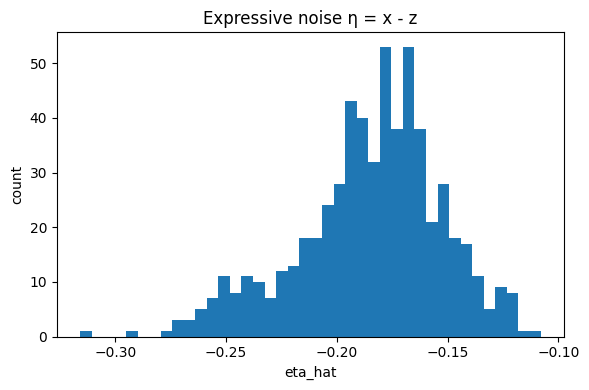

In [ ]:
# Audit / proof cell (simplified, matplotlib only)
print('Data sources:')
if USE_GLOBAL_LATENT and (RUN_DIR / GLOBAL_LATENT_FILENAME).exists():
    print('  z from:', RUN_DIR / GLOBAL_LATENT_FILENAME, f"(field='{GLOBAL_LATENT_FIELD}')")
    print('  x from:', RUN_DIR / GLOBAL_LATENT_FILENAME, "(field='obs_x')")
    print('  social from:', RUN_DIR / GLOBAL_LATENT_FILENAME, "(field='social')")
else:
    print('  z from:', RUN_DIR / 'per_agent' / 'agent_*.jsonl')
    print('  x from:', RUN_DIR / 'messages_with_alignment.jsonl')

# Step 1/2: read latent proxy z and observed expression x
if USE_GLOBAL_LATENT and (RUN_DIR / GLOBAL_LATENT_FILENAME).exists():
    raw = load_jsonl(RUN_DIR / GLOBAL_LATENT_FILENAME)
    latent_rows, expr_rows = [], []
    for row in raw:
        if isinstance(row, dict) and '_meta' in row:
            continue
        if not isinstance(row, dict):
            continue
        t = row.get('t', None)
        agent = row.get('agent', None)
        if t is None or agent is None:
            continue
        try:
            t = int(t)
        except Exception:
            continue

        z_val = row.get(GLOBAL_LATENT_FIELD, None)
        x_val = row.get('obs_x', None)

        latent_rows.append(
            {
                't': t,
                'target': str(agent),
                'obs_z_direct': float(z_val) if z_val is not None else np.nan,
                'social_direct': float(row.get('social')) if row.get('social') is not None else np.nan,
            }
        )
        expr_rows.append({'t': t, 'obs_x_direct': float(x_val) if x_val is not None else np.nan})

    latent_df = pd.DataFrame(latent_rows)
    expr_df = pd.DataFrame(expr_rows)
else:
    latent_rows = []
    for fp in sorted((RUN_DIR / 'per_agent').glob('agent_*.jsonl')):
        target = fp.stem
        for row in load_jsonl(fp):
            topo = row.get('topology_profile_for_agent') or {}
            ss = topo.get('ss')
            t = row.get('message_index')
            if ss is None or t is None:
                continue
            latent_rows.append({'t': int(t), 'target': target, 'obs_z_direct': float(ss)})
    latent_df = pd.DataFrame(latent_rows)

    expr_rows = []
    for row in load_jsonl(RUN_DIR / 'messages_with_alignment.jsonl'):
        idx = row.get('index')
        if idx is None:
            continue
        try:
            idx = int(idx)
        except Exception:
            continue
        sx = (row.get('published') or {}).get('stance_score')
        expr_rows.append({'t': idx, 'obs_x_direct': float(sx) if sx is not None else np.nan})
    expr_df = pd.DataFrame(expr_rows)

# Step 3: join and compute eta = x - z
if 'target' in latent_df.columns:
    audit_df = latent_df.merge(expr_df, on='t', how='left')
else:
    audit_df = expr_df.copy()
    audit_df['obs_z_direct'] = np.nan

audit_df['eta_direct'] = audit_df['obs_x_direct'] - audit_df['obs_z_direct']

print('\nCounts:')
print('  latent rows:', len(latent_df))
print('  expression rows:', len(expr_df))
print('  joined rows:', len(audit_df))
print('  missing x rate:', float(pd.isna(audit_df['obs_x_direct']).mean()))
display(audit_df.head(10))

# Step 4: prove implementation equation numerically (for the current runner)
alpha_audit = float(PARAMS['alpha_grid'][0])
_z_state, rec_audit, _ = run_event_fj_latent_z(load_run_data(RUN_DIR), alpha=alpha_audit)
rec_df = pd.DataFrame(rec_audit)

# Step 5: simple plots
plot_df = rec_df.copy()

plt.figure(figsize=(6, 4))
plt.scatter(plot_df['obs_z'], plot_df['obs_x'], s=8, alpha=0.25)
plt.title('Observed expression x vs latent proxy z')
plt.xlabel('obs_z')
plt.ylabel('obs_x')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(plot_df['eta_hat'].dropna(), bins=40)
plt.title('Expressive noise η = x - z')
plt.xlabel('eta_hat')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [ ]:
data = load_run_data(RUN_DIR)
print('agents=', len(data['agent_ids']), 'events=', len(data['events']))
rows = []
for a in PARAMS['alpha_grid']:
    _, rec, _ = run_event_fj_latent_z(data, alpha=a)
    m = evaluate(rec, pred_key='pred_z', obs_key='obs_z')
    rows.append({'alpha': a, 'n_eval': len(rec), **m})
res = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
res

agents= 30 events= 597


,alpha,n_eval,mae,rmse
0,0.50,597,0.039501,0.050237
1,0.55,597,0.039612,0.050320
2,0.45,597,0.039486,0.050446
3,0.60,597,0.039829,0.050693
4,0.40,597,0.039589,0.050944
5,0.65,597,0.040148,0.051351
6,0.35,597,0.040038,0.051721
7,0.70,597,0.040601,0.052282
8,0.30,597,0.040756,0.052766
9,0.75,597,0.041209,0.053472


Best: {'alpha': 0.5, 'n_eval': 597.0, 'mae': 0.03950124081134166, 'rmse': 0.050237150360939425}
Baseline metrics vs latent z(t): {'mae': 0.03950124081134166, 'rmse': 0.050237150360939425}
Diagnostic-only metrics vs observed x(t): {'mae': 0.17149949550118948, 'rmse': 0.18161185501271038}
eta mean/std: -0.18495413136918384 0.03264399241335833
belief residual mean/std: 0.013454635867994372 0.04840190130611932
expression residual mean/std: -0.17149949550118948 0.059756078552689766


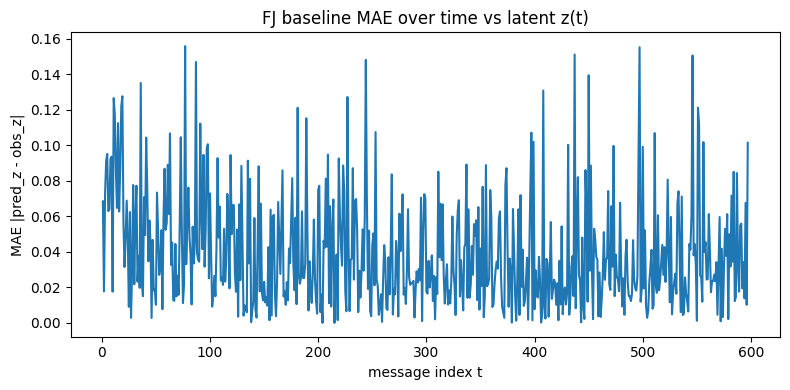

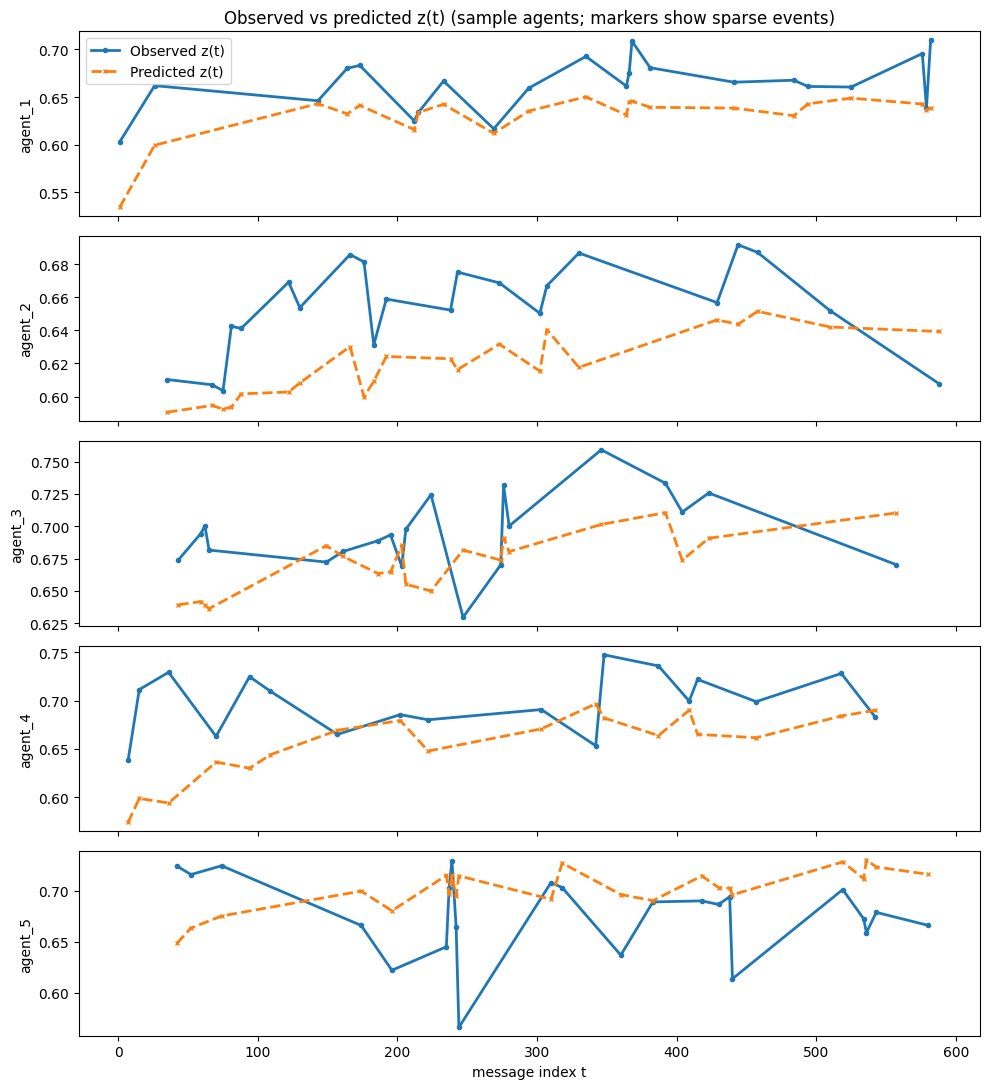

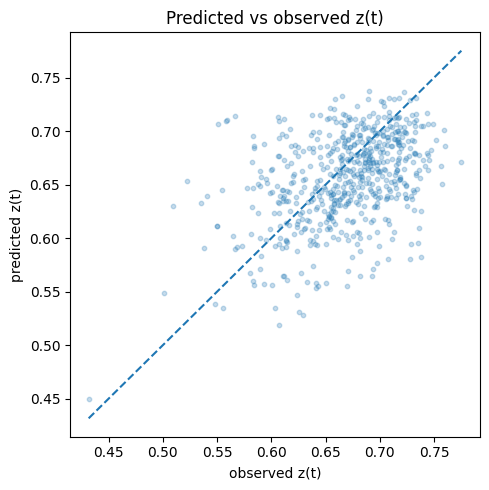

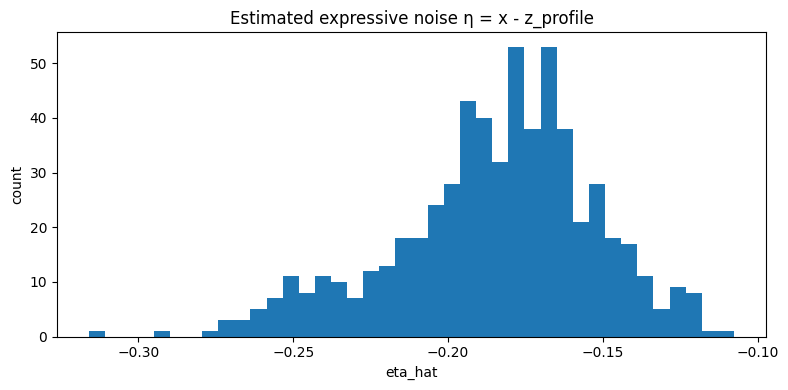

In [ ]:
best = res.iloc[0].to_dict()
print('Best:', best)
_, rec, _ = run_event_fj_latent_z(data, alpha=float(best['alpha']))
df = pd.DataFrame(rec)
valid_df = df.dropna(subset=['obs_x']).copy()
valid = valid_df.to_dict('records')
print('Baseline metrics vs latent z(t):', evaluate(rec, pred_key='pred_z', obs_key='obs_z'))
print('Diagnostic-only metrics vs observed x(t):', evaluate(valid, pred_key='pred_z', obs_key='obs_x'))
print('eta mean/std:', float(np.nanmean(df['eta_hat'])), float(np.nanstd(df['eta_hat'])))
print('belief residual mean/std:', float(np.nanmean(df['belief_resid'])), float(np.nanstd(df['belief_resid'])))
print('expression residual mean/std:', float(np.nanmean(df['expr_resid'])), float(np.nanstd(df['expr_resid'])))

df['abs_err_z'] = (df['pred_z'] - df['obs_z']).abs()
err_t = df.groupby('t', as_index=False)['abs_err_z'].mean()
plt.figure(figsize=(8, 4))
plt.plot(err_t['t'], err_t['abs_err_z'])
plt.title('FJ baseline MAE over time vs latent z(t)')
plt.xlabel('message index t')
plt.ylabel('MAE |pred_z - obs_z|')
plt.tight_layout()
plt.show()

sample_agents = sorted(df['agent'].unique(), key=numeric_agent_key)[:5]
fig, axes = plt.subplots(nrows=len(sample_agents), ncols=1, figsize=(10, 2.2 * max(1, len(sample_agents))), sharex=True)
if len(sample_agents) == 1:
    axes = [axes]
for ax, a in zip(axes, sample_agents):
    dfa = df[df['agent'] == a].sort_values('t')
    ax.plot(dfa['t'], dfa['obs_z'], color='C0', linewidth=2.0, marker='o', markersize=3, linestyle='-', label='Observed z(t)')
    ax.plot(dfa['t'], dfa['pred_z'], color='C1', linewidth=2.0, marker='x', markersize=3, linestyle='--', label='Predicted z(t)')
    ax.set_ylabel(str(a))
axes[0].legend(loc='best')
axes[0].set_title('Observed vs predicted z(t) (sample agents; markers show sparse events)')
axes[-1].set_xlabel('message index t')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(df['obs_z'], df['pred_z'], s=10, alpha=0.25)
mn = float(np.nanmin([df['obs_z'].min(), df['pred_z'].min()]))
mx = float(np.nanmax([df['obs_z'].max(), df['pred_z'].max()]))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('Predicted vs observed z(t)')
plt.xlabel('observed z(t)')
plt.ylabel('predicted z(t)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['eta_hat'].dropna(), bins=40)
plt.title('Estimated expressive noise η = x - z_profile')
plt.xlabel('eta_hat')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## Matrix Representation

For alpha-only latent-belief FJ:
$$z(t+1)=\alpha z_0 + (1-\alpha)Wz(t).$$

Set $A=(1-\alpha)W$:
$$z^*=(I-A)^{-1}\alpha z_0, \quad \rho(A)<1.$$

Expression layer remains diagnostic:
$$x_i(t)=z_i(t)+\eta_i(t).$$